# Model Output Data Visualization

### Read Me

This notebook vizualizes model outputs for supervised neural methods from the rPPG Toolbox. To use this notebook follow the following steps:

* STEP 1: Specify the `TEST.OUTPUT_SAVE_DIR` field in the `.yaml` config file of a neural method experiment.
* STEP 2: Run the neural method experiment. A `.pickle` file containing the test-data predictions and labels will be created in `TEST.OUTPUT_SAVE_DIR`.
* STEP 3: Add the path to the `pickle` file in the `TODO: Variable to Set` section as `data_out_path`.
* STEP 4: Add values for `trial_idx` (a value between 0 and the `Num Trials` print in the previous cell), `chunk_size` (number of samples to plot out), `chunk_num` (the chunk of size `chunk_size` in the signal). We suggest using the defaults at first.
* STEP 5: Run all cells. The predicted output, plotted against the ground truth ppg waveform, will be plotted in the final cell

### Imports

In [19]:
# !pip install natsort
!pip install scipy
# !pip install natsort
# !pip install ipywidgets

import cv2
import pickle
import numpy as np
import os
import matplotlib.pyplot as plt
import re

import torch

import numpy as np
# import ipywidgets as widgets
from IPython.display import display, clear_output
from natsort import natsorted
import os
import scipy
from scipy.sparse import spdiags
from scipy.signal import butter
import math
from scipy import linalg
from scipy import signal
from scipy import sparse
from typing import Dict

### Helper Functions

In [20]:
from typing import Dict
import torch

def _reform_data_for_task(data_dict: Dict[int, torch.Tensor], flatten=True):
    sorted_chunks = [data_dict[k] for k in sorted(data_dict)]
    cat = torch.cat(sorted_chunks, dim=0)
    arr = cat.cpu().numpy()
    return arr if flatten else arr.reshape(-1, 1)

# your existing band-pass/detrend helper
def _process_rppg(sig, fs, diff_flag):
    if diff_flag: sig = np.cumsum(sig)
    sig = _detrend(sig, λ=100)
    b, a = butter(1, [0.75/fs*2, 2.5/fs*2], btype='bandpass')
    return signal.filtfilt(b, a, sig)


In [21]:
# # CELL: Helper to stitch chunked predictions for a given task
# def _reform_data_for_task(data_dict: Dict[int, torch.Tensor], flatten=True):
#     """
#     data_dict: {chunk_idx: Tensor[D]}
#     returns 1-D numpy array of length = num_chunks*D
#     """
#     # sort by chunk index
#     sorted_chunks = [data_dict[k] for k in sorted(data_dict)]
#     cat = torch.cat(sorted_chunks, dim=0)           # [num_chunks * D]
#     arr = cat.cpu().numpy()
#     return arr if flatten else arr.reshape(-1, 1)


In [31]:
# HELPER FUNCTIONS

# def _reform_data_from_dict(data, flatten=True):
#     """Helper func for calculate metrics: reformat predictions and labels from dicts. """
#     sort_data = sorted(data.items(), key=lambda x: x[0])
#     sort_data = [i[1] for i in sort_data]
#     sort_data = torch.cat(sort_data, dim=0)

#     if flatten:
#         sort_data = np.reshape(sort_data.cpu(), (-1))
#     else:
#         sort_data = np.array(sort_data.cpu())

#     return sort_data

def _process_signal(signal, fs=30, diff_flag=True):
    # Detrend and filter
    use_bandpass = True
    if diff_flag:  # if the predictions and labels are 1st derivative of PPG signal.
        gt_bvp = _detrend(np.cumsum(signal), 100)
    else:
        gt_bvp = _detrend(signal, 100)
    if use_bandpass:
        # bandpass filter between [0.75, 2.5] Hz
        # equals [45, 150] beats per min
        [b, a] = butter(1, [0.75 / fs * 2, 2.5 / fs * 2], btype='bandpass')
        signal = scipy.signal.filtfilt(b, a, np.double(signal))
    return signal

def _detrend(input_signal, lambda_value):
    """Detrend PPG signal."""
    signal_length = input_signal.shape[0]
    # observation matrix
    H = np.identity(signal_length)
    ones = np.ones(signal_length)
    minus_twos = -2 * np.ones(signal_length)
    diags_data = np.array([ones, minus_twos, ones])
    diags_index = np.array([0, 1, 2])
    D = spdiags(diags_data, diags_index,
                (signal_length - 2), signal_length).toarray()
    detrended_signal = np.dot(
        (H - np.linalg.inv(H + (lambda_value ** 2) * np.dot(D.T, D))), input_signal)
    return detrended_signal


### TODO: Variables To Set

In [23]:
data_out_path = r"D:\work\UoM\FYP\proposal\Selected proposal\freq_loss\PURE_PURE_PURE_PhysMambaSF_fc_sig_round_mlti_shrdMLP_tasknorm_samedim_moe_pertsk_scalefuse0_3layer_all_config_fftnew_Epoch199_PURE_outputs.pickle"  # Output Data Path 
data_out_path = r"D:\work\UoM\FYP\proposal\Selected proposal\freq_loss\PURE_PURE_PURE_PhysMambaSF_fc_sig_round_mlti_shrdMLP_tasknorm_samedim_moe_pertsk_scalefuse0_3layer_all_config_oldfreqloss_harm_13_STFT0_Epoch49_PURE_outputs.pickle"  # Input Data Path
# Load the data 
trial_idx = 5
chunk_size = 128 # size of chunk to visualize: -1 will plot the entire signal
chunk_num = 0

### Read Data, and Extract Trials List

In [24]:
data

{'predictions': ({'1001': {0: tensor([-0.0165, -0.0032, -0.0012,  0.0109,  0.0410,  0.0691,  0.0680,  0.0260,
            -0.0273, -0.0724, -0.0746, -0.0757, -0.0709, -0.0630, -0.0606, -0.0594,
            -0.0603, -0.0616, -0.0622, -0.0616, -0.0613, -0.0582, -0.0577, -0.0401,
            -0.0073,  0.0277,  0.0367,  0.0191, -0.0189, -0.0589, -0.0707, -0.0770,
            -0.0738, -0.0702, -0.0696, -0.0650, -0.0580, -0.0544, -0.0578, -0.0605,
            -0.0616, -0.0616, -0.0623, -0.0601, -0.0546, -0.0363, -0.0117,  0.0141,
             0.0236,  0.0134, -0.0163, -0.0546, -0.0687, -0.0745, -0.0735, -0.0714,
            -0.0692, -0.0626, -0.0576, -0.0577, -0.0641, -0.0674, -0.0668, -0.0623,
            -0.0577, -0.0511, -0.0522, -0.0487, -0.0378, -0.0119,  0.0143,  0.0206,
            -0.0036, -0.0383, -0.0603, -0.0749, -0.0730, -0.0697, -0.0689, -0.0668,
            -0.0639, -0.0621, -0.0635, -0.0638, -0.0628, -0.0598, -0.0584, -0.0558,
            -0.0554, -0.0448, -0.0240,  0.0045,  0

In [25]:
# CELL: Read in data and list rPPG trials
import pickle

with open(data_out_path, 'rb') as f:
    data = pickle.load(f)

# In multi-task mode, data['predictions'] is a tuple: (rppg_dict, spo2_dict)
preds = data['predictions']
if isinstance(preds, tuple) and len(preds) == 2:
    rppg_preds, spo2_preds = preds
else:
    # single-task case
    rppg_preds = preds

# Now list all the rPPG trials (subject/video IDs)
trial_list = list(rppg_preds.keys())
print(f'Found {len(trial_list)} rPPG trials:')
print(trial_list)


Found 12 rPPG trials:
['1001', '1002', '1003', '1004', '1005', '1006', '901', '902', '903', '904', '905', '906']


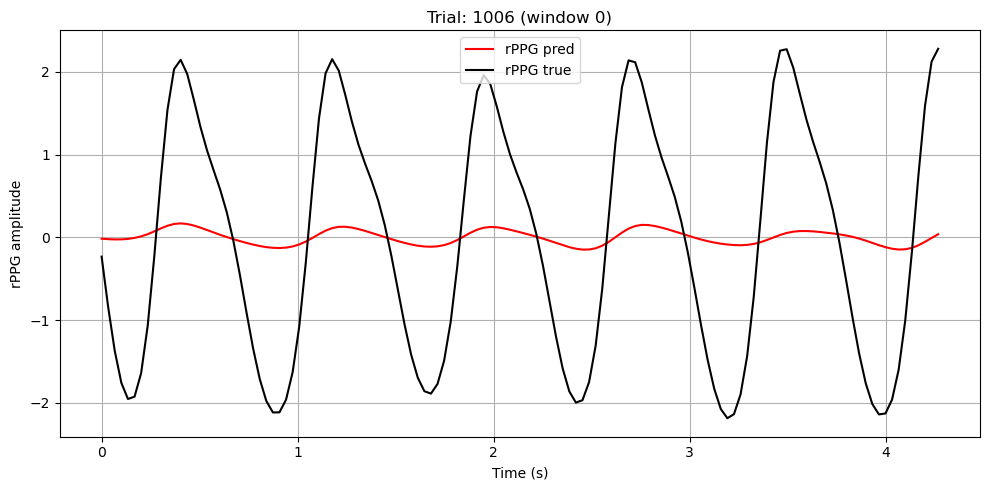

In [26]:
# CELL: Reform & visualize rPPG for one trial (fixed _detrend call)
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open(data_out_path, 'rb') as f:
    data = pickle.load(f)

# Unpack multi-task preds/labels
preds, labs = data['predictions'], data['labels']
if isinstance(preds, tuple):
    rppg_preds, _ = preds
    rppg_labels, _ = labs
else:
    rppg_preds, rppg_labels = preds, labs

trial_id = trial_list[trial_idx]
prediction = _reform_data_for_task(rppg_preds[trial_id])
label      = _reform_data_for_task(rppg_labels[trial_id])

fs        = data['fs']
diff_flag = (data['label_type'] == 'DiffNormalized')

if chunk_size == -1:
    chunk_size, chunk_num = len(prediction), 0

# Clean signals
# → correct call to _detrend using `lambda_value`
def _process_rppg(sig, fs, diff_flag):
    if diff_flag:
        sig = np.cumsum(sig)
    sig = _detrend(sig, lambda_value=100)
    b, a = butter(1, [0.75/fs*2, 2.5/fs*2], btype='bandpass')
    return signal.filtfilt(b, a, sig)

prediction = _process_rppg(prediction, fs, diff_flag)
label      = _process_rppg(label,      fs, diff_flag)

# Plot window
start = chunk_num * chunk_size
stop  = start + chunk_size
t     = np.linspace(0, (stop-start)/fs, stop-start)

plt.figure(figsize=(10,5))
plt.plot(t, prediction[start:stop], 'r', label='rPPG pred')
plt.plot(t, label[     start:stop], 'k', label='rPPG true')
plt.title(f'Trial: {trial_id} (window {chunk_num})')
plt.xlabel('Time (s)')
plt.ylabel('rPPG amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()


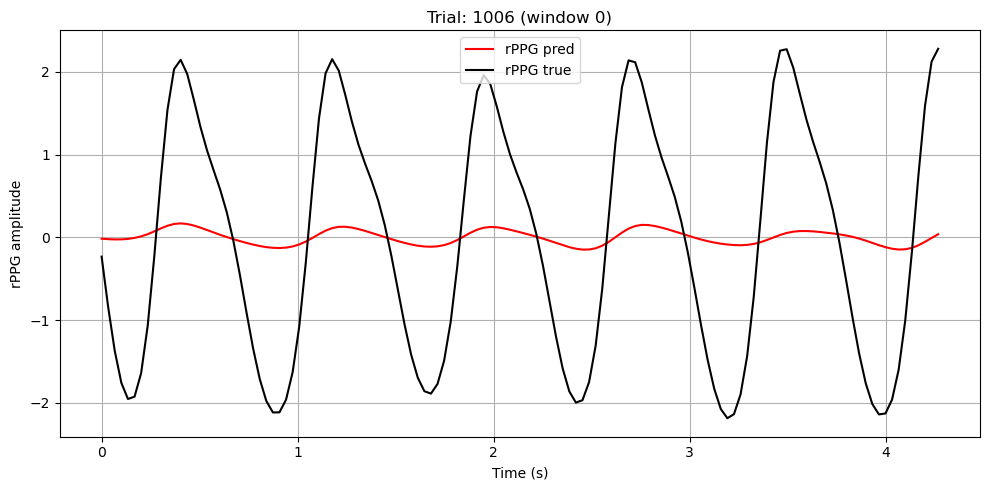

In [15]:
# CELL: Reform & visualize rPPG for one trial (fixed _detrend call)
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open(data_out_path, 'rb') as f:
    data = pickle.load(f)

# Unpack multi-task preds/labels
preds, labs = data['predictions'], data['labels']
if isinstance(preds, tuple):
    rppg_preds, _ = preds
    rppg_labels, _ = labs
else:
    rppg_preds, rppg_labels = preds, labs

trial_id = trial_list[trial_idx]
prediction = _reform_data_for_task(rppg_preds[trial_id])
label      = _reform_data_for_task(rppg_labels[trial_id])

fs        = data['fs']
diff_flag = (data['label_type'] == 'DiffNormalized')

if chunk_size == -1:
    chunk_size, chunk_num = len(prediction), 0

# Clean signals
# → correct call to _detrend using `lambda_value`
def _process_rppg(sig, fs, diff_flag):
    if diff_flag:
        sig = np.cumsum(sig)
    sig = _detrend(sig, lambda_value=100)
    b, a = butter(1, [0.75/fs*2, 2.5/fs*2], btype='bandpass')
    return signal.filtfilt(b, a, sig)

prediction = _process_rppg(prediction, fs, diff_flag)
label      = _process_rppg(label,      fs, diff_flag)

# Plot window
start = chunk_num * chunk_size
stop  = start + chunk_size
t     = np.linspace(0, (stop-start)/fs, stop-start)

plt.figure(figsize=(10,5))
plt.plot(t, prediction[start:stop], 'r', label='rPPG pred')
plt.plot(t, label[     start:stop], 'k', label='rPPG true')
plt.title(f'Trial: {trial_id} (window {chunk_num})')
plt.xlabel('Time (s)')
plt.ylabel('rPPG amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()


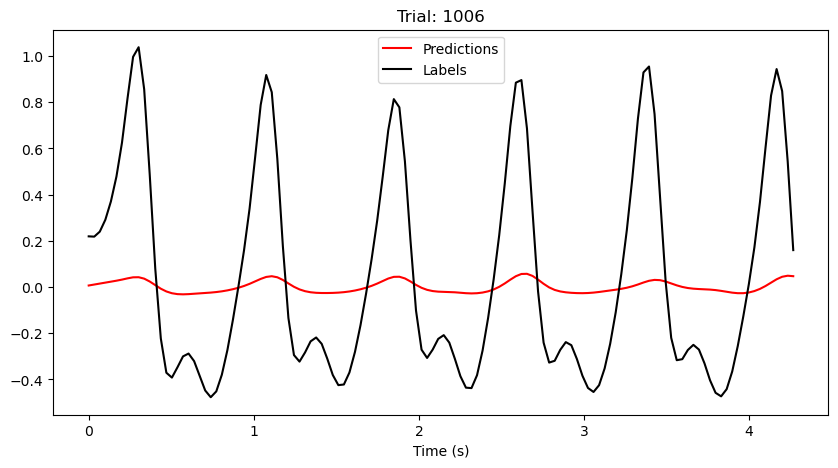

In [ ]:
# right after loading `data`:
rppg_preds_dict, spo2_preds_dict = data['predictions']
rppg_labels_dict, spo2_labels_dict = data['labels']

# now pick your trial by string key:
trial_id = trial_list[trial_idx]

prediction = np.array(_reform_data_for_task(rppg_preds_dict[trial_id]))
label      = np.array(_reform_data_for_task(rppg_labels_dict[trial_id]))

# Read in meta-data from pickle file
fs = data['fs'] # Video Frame Rate
label_type = data['label_type'] # PPG Signal Transformation: `DiffNormalized` or `Standardized`
diff_flag = (label_type == 'DiffNormalized')

if chunk_size == -1:
    chunk_size = len(prediction)
    chunk_num = 0

# Process label and prediction signals
prediction = _process_signal(prediction, fs, diff_flag=diff_flag)
label = _process_signal(label, fs, diff_flag=diff_flag)
start = (chunk_num)*chunk_size
stop = (chunk_num+1)*chunk_size
samples = stop - start
x_time = np.linspace(0, samples/fs, num=samples)

plt.figure(figsize=(10,5))
plt.plot(x_time, prediction[start:stop], color='r')
plt.plot(x_time, label[start:stop], color='black')
plt.title('Trial: ' + trial_list[trial_idx])
plt.legend(['Predictions', 'Labels'])
plt.xlabel('Time (s)');

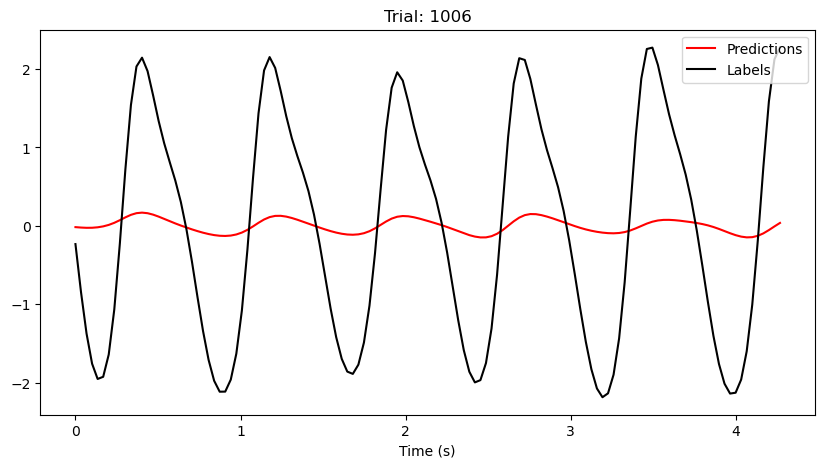

In [33]:
# right after loading `data`:
rppg_preds_dict, spo2_preds_dict = data['predictions']
rppg_labels_dict, spo2_labels_dict = data['labels']

# now pick your trial by string key:
trial_id = trial_list[trial_idx]

prediction = np.array(_reform_data_for_task(rppg_preds_dict[trial_id]))
label      = np.array(_reform_data_for_task(rppg_labels_dict[trial_id]))

# Read in meta-data from pickle file
fs = data['fs'] # Video Frame Rate
label_type = data['label_type'] # PPG Signal Transformation: `DiffNormalized` or `Standardized`
diff_flag = (label_type == 'DiffNormalized')

if chunk_size == -1:
    chunk_size = len(prediction)
    chunk_num = 0

# Process label and prediction signals
prediction = _process_rppg(prediction, fs, diff_flag=diff_flag)
label = _process_rppg(label, fs, diff_flag=diff_flag)
start = (chunk_num)*chunk_size
stop = (chunk_num+1)*chunk_size
samples = stop - start
x_time = np.linspace(0, samples/fs, num=samples)

plt.figure(figsize=(10,5))
plt.plot(x_time, prediction[start:stop], color='r')
plt.plot(x_time, label[start:stop], color='black')
plt.title('Trial: ' + trial_list[trial_idx])
plt.legend(['Predictions', 'Labels'])
plt.xlabel('Time (s)');

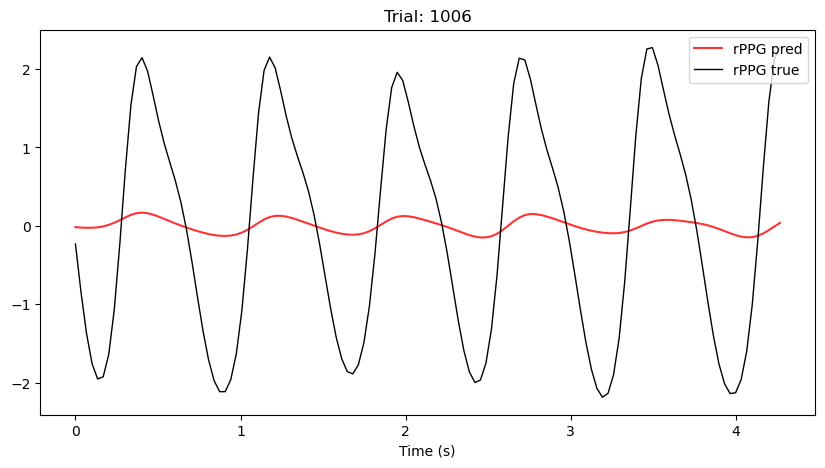

In [16]:
# ─── Reform and plot rPPG for a multi-task pickle ───

# 1) Load
with open(data_out_path, 'rb') as f:
    data = pickle.load(f)

# 2) Unpack predictions/labels
preds = data['predictions']
if isinstance(preds, tuple) and len(preds) == 2:
    rppg_preds, spo2_preds = preds
else:
    rppg_preds = preds

labs = data['labels']
if isinstance(labs, tuple) and len(labs) == 2:
    hr_labels, spo2_labels = labs
else:
    hr_labels = labs

# 3) Pick trial
trial_id = trial_list[trial_idx]

# 4) Stitch chunks → 1-D arrays
prediction = _reform_data_for_task(rppg_preds[trial_id])
label      = _reform_data_for_task(hr_labels [trial_id])

# 5) Meta
fs         = data['fs']
label_type = data['label_type']
diff_flag  = (label_type == 'DiffNormalized')

# 6) Select window
if chunk_size == -1:
    chunk_size = len(prediction)
    chunk_num  = 0
start = chunk_num * chunk_size
stop  = start + chunk_size

# 7) Clean signals
prediction = _process_rppg(prediction, fs, diff_flag)
label      = _process_rppg(label,      fs, diff_flag)

# 8) Time axis
t = np.linspace(0, (stop-start)/fs, stop-start)

# 9) Plot
plt.figure(figsize=(10,5))
plt.plot(t, prediction[start:stop], 'r', alpha=0.8)
plt.plot(t, label[     start:stop], 'k', lw=1)
plt.title(f'Trial: {trial_id}')
plt.legend(['rPPG pred','rPPG true'])
plt.xlabel('Time (s)')
plt.show()
